In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

BỘ DỮ LIỆU CỦA GPR

In [66]:
gpr = pd.read_excel("/content/drive/MyDrive/DACS_2/data/data_gpr_daily_recent (3).xls")

In [67]:
gpr.head()

,DAY,N10D,GPRD,GPRD_ACT,GPRD_THREAT,date,GPRD_MA30,GPRD_MA7,event,var_name,var_label
0,19850101,216,230.039429,275.197601,153.027985,1985-01-01,230.039429,230.039429,NaN,DAY,DAY
1,19850102,315,115.676971,146.772064,87.444572,1985-01-02,172.858200,172.858200,NaN,N10D,"Number of articles (10 recent newspapers, 1985-)"
2,19850103,374,97.428459,158.937653,29.459934,1985-01-03,147.714951,147.714951,NaN,GPRD,Daily GPR (Index: 1985:2019=100)
3,19850104,421,157.366638,156.882248,157.026352,1985-01-04,150.127869,150.127869,NaN,GPRD_ACT,Daily GPR Acts (Index: 1985:2019=100)
4,19850105,285,81.361313,92.698143,77.319405,1985-01-05,136.374557,136.374557,NaN,GPRD_THREAT,Daily GPR Threats (Index: 1985:2019=100)


In [68]:
gpr.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14917 entries, 0 to 14916
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   DAY          14917 non-null  int64         
 1   N10D         14917 non-null  int64         
 2   GPRD         14917 non-null  float64       
 3   GPRD_ACT     14917 non-null  float64       
 4   GPRD_THREAT  14917 non-null  float64       
 5   date         14917 non-null  datetime64[ns]
 6   GPRD_MA30    14917 non-null  float64       
 7   GPRD_MA7     14917 non-null  float64       
 8   event        11 non-null     object        
 9   var_name     9 non-null      object        
 10  var_label    9 non-null      object        
dtypes: datetime64[ns](1), float64(5), int64(2), object(3)
memory usage: 1.3+ MB


In [69]:
gpr.isnull().sum()

,0
DAY,0
N10D,0
GPRD,0
GPRD_ACT,0
GPRD_THREAT,0
date,0
GPRD_MA30,0
GPRD_MA7,0
event,14906
var_name,14908


Kiểm tra dữ liệu ban đầu

In [70]:
# Kiểm tra tên cột
print(gpr.columns)

# Kiểm tra dữ liệu thiếu
print(gpr.isna().sum())

# Kiểm tra ngày nhỏ nhất và lớn nhất
print(gpr["date"].min())
print(gpr["date"].max())

# Kiểm tra dòng trùng ngày
print("Số ngày trùng:", gpr["date"].duplicated().sum())

Index(['DAY', 'N10D', 'GPRD', 'GPRD_ACT', 'GPRD_THREAT', 'date', 'GPRD_MA30',
       'GPRD_MA7', 'event', 'var_name', 'var_label'],
      dtype='object')
DAY                0
N10D               0
GPRD               0
GPRD_ACT           0
GPRD_THREAT        0
date               0
GPRD_MA30          0
GPRD_MA7           0
event          14906
var_name       14908
var_label      14908
dtype: int64
1985-01-01 00:00:00
2025-11-03 00:00:00
Số ngày trùng: 0


Làm sạch dữ liệu GPR

In [71]:
# Đổi tên cột cho dễ hiểu
gpr = gpr.rename(columns={
    "date": "Date",
    "N10D": "News_Count_10",
    "event": "Event_Label"
})

# Bỏ các cột không cần thiết nếu có
drop_cols = ["DAY", "var_name", "var_label"]

gpr = gpr.drop(
    columns=[col for col in drop_cols if col in gpr.columns]
)

# Chuyển cột Date về dạng ngày
gpr["Date"] = pd.to_datetime(gpr["Date"])

# Sắp xếp theo thời gian
gpr = gpr.sort_values("Date")

# Xóa ngày trùng nếu có
gpr = gpr.drop_duplicates(subset=["Date"])

# Reset lại index
gpr = gpr.reset_index(drop=True)

print(gpr.head())
print(gpr.info())

   News_Count_10        GPRD    GPRD_ACT  GPRD_THREAT       Date   GPRD_MA30  \
0            216  230.039429  275.197601   153.027985 1985-01-01  230.039429   
1            315  115.676971  146.772064    87.444572 1985-01-02  172.858200   
2            374   97.428459  158.937653    29.459934 1985-01-03  147.714951   
3            421  157.366638  156.882248   157.026352 1985-01-04  150.127869   
4            285   81.361313   92.698143    77.319405 1985-01-05  136.374557   

     GPRD_MA7 Event_Label  
0  230.039429         NaN  
1  172.858200         NaN  
2  147.714951         NaN  
3  150.127869         NaN  
4  136.374557         NaN  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14917 entries, 0 to 14916
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   News_Count_10  14917 non-null  int64         
 1   GPRD           14917 non-null  float64       
 2   GPRD_ACT       14917 non-null  flo

Xử lý cột sự kiện

In [72]:
gpr["Has_GPR_Event"] = gpr["Event_Label"].notna().astype(int)

gpr["Event_Label"] = gpr["Event_Label"].fillna("")

print(gpr[["Date", "GPRD", "Event_Label", "Has_GPR_Event"]].head())

        Date        GPRD Event_Label  Has_GPR_Event
0 1985-01-01  230.039429                          0
1 1985-01-02  115.676971                          0
2 1985-01-03   97.428459                          0
3 1985-01-04  157.366638                          0
4 1985-01-05   81.361313                          0


Lọc giai đoạn

In [73]:
start_date = "2008-05-01"
end_date = "2025-11-03"

gpr = gpr[
    (gpr["Date"] >= start_date) &
    (gpr["Date"] <= end_date)
].copy()

print("Thời gian sau khi lọc:")
print(gpr["Date"].min(), "→", gpr["Date"].max())

print("Số dòng sau khi lọc:", gpr.shape[0])

Thời gian sau khi lọc:
2008-05-01 00:00:00 → 2025-11-03 00:00:00
Số dòng sau khi lọc: 6396


Xoá MA7 và MA30

In [74]:
gpr = gpr.drop(columns=["GPRD_MA7", "GPRD_MA30"])
print(gpr.head())

      News_Count_10       GPRD    GPRD_ACT  GPRD_THREAT       Date  \
8521           1245  90.463699  100.795265    88.498108 2008-05-01   
8522           1094  57.530880   84.521385    30.213936 2008-05-02   
8523           1226  64.846352   59.259518    62.908733 2008-05-03   
8524            740  71.623085  107.103935    44.667629 2008-05-04   
8525            866  42.076496   53.387062    38.168644 2008-05-05   

     Event_Label  Has_GPR_Event  
8521                          0  
8522                          0  
8523                          0  
8524                          0  
8525                          0  


### Biểu đồ ACF và PACF của GPRD

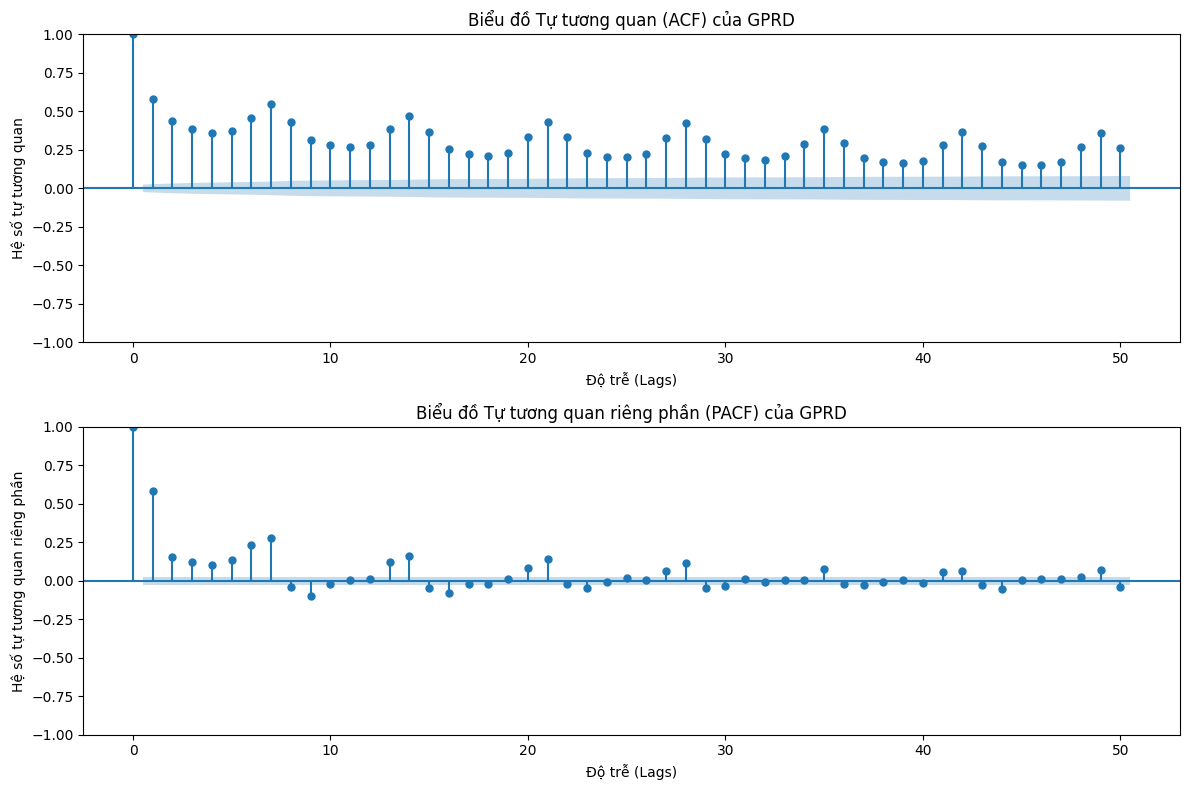

In [75]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# ACF plot
plot_acf(gpr['GPRD'], lags=50, ax=axes[0])
axes[0].set_title('Biểu đồ Tự tương quan (ACF) của GPRD')
axes[0].set_xlabel('Độ trễ (Lags)')
axes[0].set_ylabel('Hệ số tự tương quan')

# PACF plot
plot_pacf(gpr['GPRD'], lags=50, ax=axes[1])
axes[1].set_title('Biểu đồ Tự tương quan riêng phần (PACF) của GPRD')
axes[1].set_xlabel('Độ trễ (Lags)')
axes[1].set_ylabel('Hệ số tự tương quan riêng phần')

plt.tight_layout()
plt.show()

Nhận xét về biểu đồ:
- **ACF (Autocorrelation Function):** Các đường tự tương quan giảm dần nhưng chậm cho thấy sự phụ thuộc vào các giá trị quá khứ vẫn còn đáng kể ở các độ trễ cao.
- **PACF (Partial Autocorrelation Function):** Đường tự tương quan riêng phần sẽ giúp xác định độ trễ mà tại đó mối quan hệ trực tiếp (không thông qua các độ trễ trung gian) là mạnh nhất. Độ trễ nào có thanh vượt ra ngoài vùng màu xanh lam (khoảng tin cậy) là đáng chú ý.

### Biểu đồ Tương quan giữa các biến

News_Count_10 là số lượng/tổng chỉ báo tin tức được ghi nhận từ 10 tờ báo dùng để xây dựng chỉ số GPR hằng ngày.

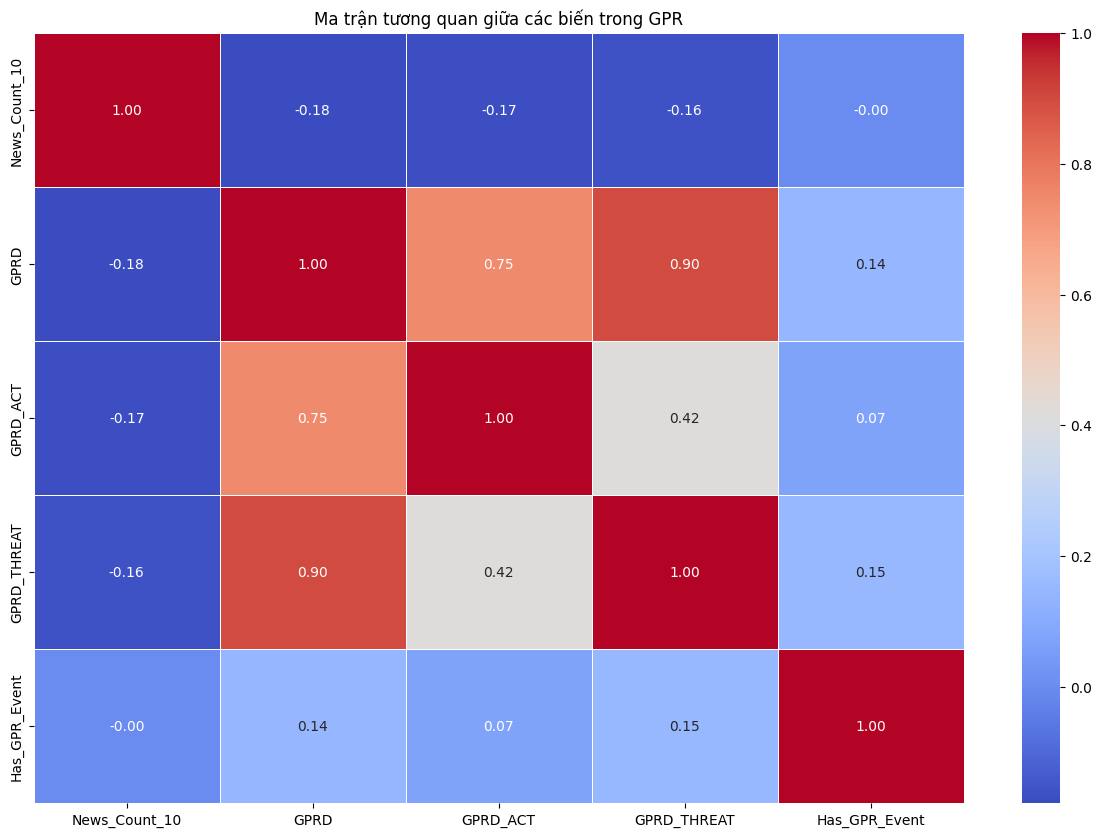

In [76]:
# Tính toán ma trận tương quan
corr_matrix = gpr.corr(numeric_only=True)

# Vẽ heatmap
plt.figure(figsize=(15, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Ma trận tương quan giữa các biến trong GPR')
plt.show()

LƯU FILE GPR

In [78]:
gpr_clean = gpr[
    [
        "Date",
        "News_Count_10",
        "GPRD",
        "GPRD_ACT",
        "GPRD_THREAT",
        "Has_GPR_Event"
    ]
].copy()

gpr_clean.to_csv("gpr_clean.csv", index=False, encoding="utf-8-sig")

print(gpr_clean.head())
print(gpr_clean.info())

           Date  News_Count_10       GPRD    GPRD_ACT  GPRD_THREAT  \
8521 2008-05-01           1245  90.463699  100.795265    88.498108   
8522 2008-05-02           1094  57.530880   84.521385    30.213936   
8523 2008-05-03           1226  64.846352   59.259518    62.908733   
8524 2008-05-04            740  71.623085  107.103935    44.667629   
8525 2008-05-05            866  42.076496   53.387062    38.168644   

      Has_GPR_Event  
8521              0  
8522              0  
8523              0  
8524              0  
8525              0  
<class 'pandas.core.frame.DataFrame'>
Index: 6396 entries, 8521 to 14916
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Date           6396 non-null   datetime64[ns]
 1   News_Count_10  6396 non-null   int64         
 2   GPRD           6396 non-null   float64       
 3   GPRD_ACT       6396 non-null   float64       
 4   GPRD_THREAT    6396 non-null   